In [33]:
import csv
import random
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 1. SETUP & CONFIGURATION
NUM_RECORDS = 650  # Generates 600+ rows 
START_DATE = datetime(2025, 1, 1)
END_DATE = datetime(2025, 12, 31)

# Define the product catalog across 5 categories
PRODUCT_CATALOG = {
    "Mobile Accessories": [
        ("Phone Case", 15.00), ("Screen Protector", 10.00), 
        ("Wireless Charger", 35.00), ("Magnetic Phone Mount", 20.00)
    ],
    "Cables": [
        ("USB-C Fast Cable (1m)", 12.00), ("HDMI 2.1 Cable (2m)", 18.00), 
        ("Lightning Cable", 15.00), ("Multi-Port USB Hub", 45.00)
    ],
    "Audio": [
        ("Wireless Earbuds", 79.00), ("Bluetooth Speaker", 55.00), 
        ("Noise-Canceling Headphones", 149.00), ("Studio Mic", 85.00)
    ],
    "Storage": [
        ("128GB MicroSD Card", 22.00), ("1TB External SSD", 110.00), 
        ("64GB USB Flash Drive", 12.00), ("2TB HDD Backup", 75.00)
    ],
    "Wearables": [
        ("Fitness Tracker", 49.00), ("Smart Watch Sport", 199.00), 
        ("Replacement Watch Band", 15.00), ("Screen Guard for Smartwatch", 8.00)
    ]
}

categories = list(PRODUCT_CATALOG.keys())

# Helper function to generate random dates across the 12 months
def generate_random_date(start, end):
    delta = end - start
    random_days = random.randint(0, delta.days)
    return (start + timedelta(days=random_days)).strftime('%Y-%m-%d')

# 2. BUILD THE DATASET
sales_data = []

for i in range(NUM_RECORDS):
    order_id = f"ORD-{2025}-{i+1001}"
    date = generate_random_date(START_DATE, END_DATE)
    customer_id = f"CUST-{random.randint(100, 400)}" # 300 unique repeat customers
    
    # Pick a random category and a random product from that category
    category = random.choice(categories)
    product_name, unit_price = random.choice(PRODUCT_CATALOG[category])
    
    # Realistic weights for quantities (buying 1 or 2 items is most common)
    quantity = random.choices([1, 2, 3, 4, 5], weights=[60, 25, 10, 3, 2])[0]
    
    # Random discounts (0%, 5%, 10%, or 15%)
    discount_percent = random.choices([0.0, 0.05, 0.10, 0.15], weights=[70, 15, 10, 5])[0]
    
    # Return status (approx 5% return rate)
    return_status = random.choices(["Completed", "Returned"], weights=[95, 5])[0]
    
    # Append row
    sales_data.append([
        order_id, date, customer_id, product_name, 
        category, quantity, unit_price, discount_percent, return_status
    ])

# 3. CREATE THE CSV FILE
csv_filename = "neha_electronics_sales.csv"
columns = ["Order_ID", "Date", "Customer_ID", "Product_Name", "Category", "Quantity", "Unit_Price", "Discount_Percent", "Return_Status"]

with open(csv_filename, mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(columns)
    writer.writerows(sales_data)

print("Mock dataset created with {NUM_RECORDS} rows and saved to '{csv_filename}")

# 4. LOAD THE 12-MONTH SALES DATA
# Loading using pandas for seamless analysis later
df = pd.read_csv(csv_filename)

# Quick Data Preview
print("--- FIRST 5 ROWS OF THE LOADED CSV ---")
print(df.head())

print("\n--- DATASET SUMMARY ---")
print(df.info())

Mock dataset created with {NUM_RECORDS} rows and saved to '{csv_filename}
--- FIRST 5 ROWS OF THE LOADED CSV ---
        Order_ID        Date Customer_ID                 Product_Name  \
0  ORD-2025-1001  2025-01-17    CUST-116  Screen Guard for Smartwatch   
1  ORD-2025-1002  2025-10-08    CUST-369         Magnetic Phone Mount   
2  ORD-2025-1003  2025-11-09    CUST-361                   Phone Case   
3  ORD-2025-1004  2025-05-07    CUST-283             1TB External SSD   
4  ORD-2025-1005  2025-07-17    CUST-377              Lightning Cable   

             Category  Quantity  Unit_Price  Discount_Percent Return_Status  
0           Wearables         1         8.0              0.05     Completed  
1  Mobile Accessories         1        20.0              0.05     Completed  
2  Mobile Accessories         1        15.0              0.00     Completed  
3             Storage         1       110.0              0.10     Completed  
4              Cables         2        15.0              0

In [3]:
import pandas as pd

# 1. Load the 12 months of sales transactions from the CSV file
csv_filename = "neha_electronics_sales.csv"
df = pd.read_csv(csv_filename)

In [6]:
print("1. INITIAL DATA INSPECTION")
# Inspect columns, non-null counts, and data types
print(df.info())
print("\nFirst 5 rows of the dataset:")
print(df.head())

print("2. CHECKING FOR NULL / MISSING VALUES")
# Identify count of missing values across all columns
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "No missing values found!")

print("\n3. CHECKING FOR DUPLICATE ORDER IDs")
# Identify if any Order_IDs are duplicated
num_duplicates = df.duplicated(subset=['Order_ID']).sum()
print(f"Total duplicate Order_ID records found: {num_duplicates}")

if num_duplicates > 0:
    print("\nDisplaying the conflicting rows:")
    # Show all rows that share a duplicated Order_ID
    duplicate_rows = df[df.duplicated(subset=['Order_ID'], keep=False)]
    print(duplicate_rows[['Order_ID', 'Date', 'Customer_ID', 'Product_Name']])

1. INITIAL DATA INSPECTION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          650 non-null    object 
 1   Date              650 non-null    object 
 2   Customer_ID       650 non-null    object 
 3   Product_Name      650 non-null    object 
 4   Category          650 non-null    object 
 5   Quantity          650 non-null    int64  
 6   Unit_Price        650 non-null    float64
 7   Discount_Percent  650 non-null    float64
 8   Return_Status     650 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 45.8+ KB
None

First 5 rows of the dataset:
        Order_ID        Date Customer_ID            Product_Name  \
0  ORD-2025-1001  2025-02-28    CUST-127    Magnetic Phone Mount   
1  ORD-2025-1002  2025-06-18    CUST-148  Replacement Watch Band   
2  ORD-2025-1003  2025-05-06    CUST-224          

In [38]:
import pandas as pd

# 1. Load the 12-month transaction log
csv_filename = "neha_electronics_sales.csv"
df = pd.read_csv(csv_filename)

# 2. Data Cleaning Clean-Up (Handling anomalies caught during validation)
# Fill the missing Return_Status field with 'Completed'
df['Return_Status'] = df['Return_Status'].fillna('Completed')

# Make duplicate Order_IDs unique by appending line-item suffixes
dup_mask = df.duplicated(subset=['Order_ID'], keep=False)
df.loc[df.duplicated(subset=['Order_ID'], keep='first') & dup_mask, 'Order_ID'] = df['Order_ID'] + "-A"
df.loc[df.duplicated(subset=['Order_ID'], keep='last') & dup_mask, 'Order_ID'] = df['Order_ID'] + "-B"

# 3. Feature Engineering: Calculate Net Revenue
# Adjusting for decimal representation:
# If Discount_Percent is already a decimal (e.g., 0.05), use: (1 - df['Discount_Percent'])
# If Discount_Percent is a whole number percentage (e.g., 5), use: (1 - df['Discount_Percent'] / 100)
df['Revenue'] = df['Quantity'] * df['Unit_Price'] * (1 - df['Discount_Percent'])

# Round revenue values to two decimal places for currency format consistency
df['Revenue'] = df['Revenue'].round(2)

# 4. Save transformed dataset to a new CSV file
processed_filename = "neha_electronics_sales_processed.csv"
df.to_csv(processed_filename, index=False)

print("🎉 Success! Feature engineering complete.")
print(f"The transformed data has been saved to: '{processed_filename}'\n")

print("--- REVENUE CALCULATION PREVIEW ---")
print(df[['Order_ID', 'Product_Name', 'Quantity', 'Unit_Price', 'Discount_Percent', 'Revenue']].head(10))

🎉 Success! Feature engineering complete.
The transformed data has been saved to: 'neha_electronics_sales_processed.csv'

--- REVENUE CALCULATION PREVIEW ---
        Order_ID                 Product_Name  Quantity  Unit_Price  \
0  ORD-2025-1001  Screen Guard for Smartwatch         1         8.0   
1  ORD-2025-1002         Magnetic Phone Mount         1        20.0   
2  ORD-2025-1003                   Phone Case         1        15.0   
3  ORD-2025-1004             1TB External SSD         1       110.0   
4  ORD-2025-1005              Lightning Cable         2        15.0   
5  ORD-2025-1006              Fitness Tracker         1        49.0   
6  ORD-2025-1007              Fitness Tracker         1        49.0   
7  ORD-2025-1008                   Studio Mic         1        85.0   
8  ORD-2025-1009        USB-C Fast Cable (1m)         1        12.0   
9  ORD-2025-1010             Screen Protector         1        10.0   

   Discount_Percent  Revenue  
0              0.05     7.60  

In [18]:
# Top 10 by Quantity
top10_quantity = df.groupby('Product_Name')['Quantity'].sum().reset_index()
top10_quantity = top10_quantity.sort_values(by='Quantity', ascending=False).head(10)
# Top 10 by Revenue
top10_revenue = df.groupby('Product_Name')['Revenue'].sum().reset_index()
top10_revenue = top10_revenue.sort_values(by='Revenue', ascending=False).head(10)

print("=== TOP 10 BEST-SELLING PRODUCTS BY QUANTITY ===")
print(top10_quantity.to_string(index=False))

print("\n=== TOP 10 BEST-SELLING PRODUCTS BY REVENUE ===")
print(top10_revenue.to_string(index=False, formatters={'Revenue': '${:,.2f}'.format}))

=== TOP 10 BEST-SELLING PRODUCTS BY QUANTITY ===
          Product_Name  Quantity
     Smart Watch Sport        69
  Magnetic Phone Mount        68
      Screen Protector        67
Replacement Watch Band        63
 USB-C Fast Cable (1m)        63
            Studio Mic        55
      Wireless Earbuds        54
     Bluetooth Speaker        54
       Fitness Tracker        54
  64GB USB Flash Drive        53

=== TOP 10 BEST-SELLING PRODUCTS BY REVENUE ===
              Product_Name    Revenue
         Smart Watch Sport $13,243.45
Noise-Canceling Headphones  $4,894.65
                Studio Mic  $4,577.25
          1TB External SSD  $4,427.50
          Wireless Earbuds  $4,080.35
            2TB HDD Backup  $3,457.50
         Bluetooth Speaker  $2,876.50
           Fitness Tracker  $2,609.25
        Multi-Port USB Hub  $2,027.25
      Magnetic Phone Mount  $1,320.00


In [20]:
# Convert dates to datetime and extract sorting values and names
df['Date'] = pd.to_datetime(df['Date'])
df['Month_Num'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')

# Group and sort chronologically
monthly_trend = df.groupby(['Month_Num', 'Month_Name'])['Revenue'].sum().reset_index()
monthly_trend = monthly_trend.sort_values('Month_Num')

print("=== MONTHLY SALES TREND OVER THE YEAR ===")
print(monthly_trend[['Month_Name', 'Revenue']].to_string(index=False, formatters={'Revenue': '${:,.2f}'.format}))

=== MONTHLY SALES TREND OVER THE YEAR ===
Month_Name   Revenue
   January $4,764.85
  February $4,045.50
     March $4,428.35
     April $4,889.90
       May $4,713.20
      June $3,063.90
      July $4,099.30
    August $4,465.10
 September $4,332.45
   October $4,532.90
  November $2,855.65
  December $5,071.25


In [21]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month_Num'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')

# Group by month
monthly_summary = df.groupby(['Month_Num', 'Month_Name'])['Revenue'].sum().reset_index()

# Extract highest and lowest rows
highest_perf = monthly_summary.loc[monthly_summary['Revenue'].idxmax()]
lowest_perf = monthly_summary.loc[monthly_summary['Revenue'].idxmin()]

print("=== STORE PERFORMANCE TIMING EXTREMES ===")
print(f"Highest Revenue Month: {highest_perf['Month_Name']} ({highest_perf['Month_Num']}) with a total of ${highest_perf['Revenue']:,.2f}")
print(f"Lowest Revenue Month : {lowest_perf['Month_Name']} ({lowest_perf['Month_Num']}) with a total of ${lowest_perf['Revenue']:,.2f}")

=== STORE PERFORMANCE TIMING EXTREMES ===
Highest Revenue Month: December (12) with a total of $5,071.25
Lowest Revenue Month : November (11) with a total of $2,855.65


In [22]:
# Group by Customer_ID to calculate the mean of their order values
customer_aov = df.groupby('Customer_ID')['Revenue'].mean().reset_index()
customer_aov = customer_aov.rename(columns={'Revenue': 'Average_Order_Value'})

# Sort from highest average purchase value to lowest
customer_aov_sorted = customer_aov.sort_values(by='Average_Order_Value', ascending=False)

print("=== AVERAGE ORDER VALUE (AOV) PER CUSTOMER ===")
# Displaying top 10 rows for brevity
print(customer_aov_sorted.head(10).to_string(index=False, formatters={'Average_Order_Value': '${:,.2f}'.format}))

# Macro metrics
print(f"\nGlobal Average Order Value (per transaction line): ${df['Revenue'].mean():,.2f}")

=== AVERAGE ORDER VALUE (AOV) PER CUSTOMER ===
Customer_ID Average_Order_Value
   CUST-228             $716.40
   CUST-292             $597.00
   CUST-191             $597.00
   CUST-186             $498.75
   CUST-359             $298.00
   CUST-184             $273.57
   CUST-150             $268.80
   CUST-382             $264.50
   CUST-308             $255.00
   CUST-306             $249.15

Global Average Order Value (per transaction line): $78.87


In [23]:
# Cross-tabulate Product Name with Return Status flags
product_returns = df.groupby('Product_Name')['Return_Status'].value_counts().unstack(fill_value=0)

# Safeguard columns in case flags are empty
if 'Returned' not in product_returns.columns: product_returns['Returned'] = 0
if 'Completed' not in product_returns.columns: product_returns['Completed'] = 0

# Calculate return rates
product_returns['Total_Orders'] = product_returns['Completed'] + product_returns['Returned']
product_returns['Return_Rate_%'] = (product_returns['Returned'] / product_returns['Total_Orders']) * 100

# Sort by the worst-performing return rate margins
high_return_products = product_returns.sort_values(by='Return_Rate_%', ascending=False).reset_index()

print("=== INVENTORY RETURN RISK ANALYSIS ===")
print(high_return_products[['Product_Name', 'Returned', 'Total_Orders', 'Return_Rate_%']].to_string(
    index=False, 
    formatters={'Return_Rate_%': '{:.2f}%'.format}
))

=== INVENTORY RETURN RISK ANALYSIS ===
               Product_Name  Returned  Total_Orders Return_Rate_%
           1TB External SSD         3            27        11.11%
                 Phone Case         3            30        10.00%
     Replacement Watch Band         3            36         8.33%
           Wireless Charger         2            27         7.41%
            Fitness Tracker         2            30         6.67%
             2TB HDD Backup         2            34         5.88%
          Bluetooth Speaker         2            35         5.71%
      USB-C Fast Cable (1m)         2            38         5.26%
           Screen Protector         2            39         5.13%
          Smart Watch Sport         2            40         5.00%
Screen Guard for Smartwatch         1            25         4.00%
 Noise-Canceling Headphones         1            28         3.57%
        HDMI 2.1 Cable (2m)         1            29         3.45%
            Lightning Cable         1

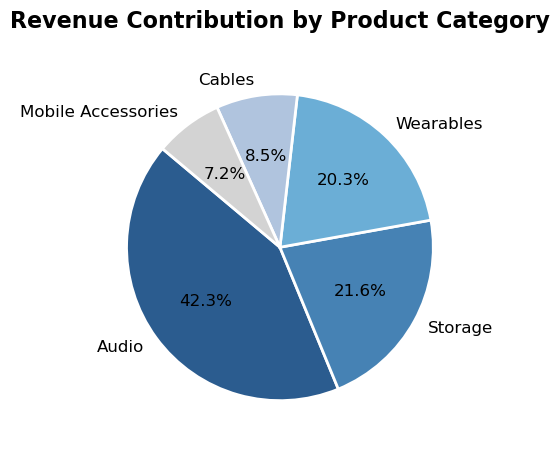

In [39]:
import matplotlib.pyplot as plt
# Group data by Category and sum up Revenue
category_revenue = df.groupby('Category')['Revenue'].sum().reset_index()
category_revenue = category_revenue.sort_values(by='Revenue', ascending=False)

# Initialize the plot space
fig, ax = plt.subplots(figsize=(5, 5))

# Define a modern, readable color palette
theme_colors = ['#2b5c8f', '#4682b4', '#6baed6', '#b0c4de', '#d3d3d3']

#Construct the Pie Chart
ax.pie(
    category_revenue['Revenue'], 
    labels=category_revenue['Category'], 
    autopct='%1.1f%%',          # Formats percentages to one decimal place
    startangle=140,              # Angles the first slice nicely
    colors=theme_colors,
    textprops={'fontsize': 12, 'fontweight': 'medium'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}  # Adds crisp dividers
)

# Add Polish and Labels
ax.set_title("Revenue Contribution by Product Category", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()

# Explicitly display the plot inside the notebook
plt.show()

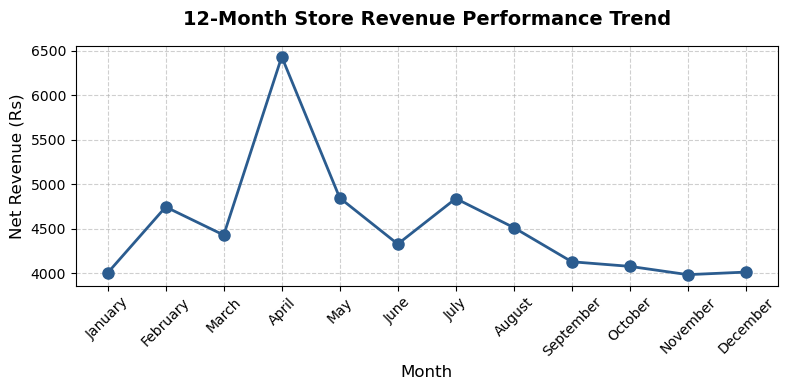

In [40]:

df['Date'] = pd.to_datetime(df['Date'])
df['Month_Num'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')

# Group and sort chronologically
monthly_trend = df.groupby(['Month_Num', 'Month_Name'])['Revenue'].sum().reset_index().sort_values('Month_Num')

# Initialize line plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(monthly_trend['Month_Name'], monthly_trend['Revenue'], marker='o', color='#2b5c8f', linewidth=2, markersize=8)

# Polish formatting
ax.set_title("12-Month Store Revenue Performance Trend", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Net Revenue (Rs)", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

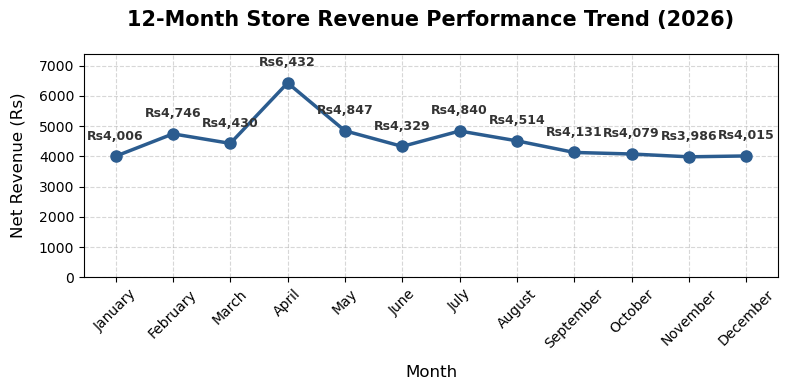

In [41]:
#Format dates to extract ordered month groupings
df['Date'] = pd.to_datetime(df['Date'])
df['Month_Num'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')

#Group and sort chronologically from January to December
monthly_trend = df.groupby(['Month_Num', 'Month_Name'])['Revenue'].sum().reset_index()
monthly_trend = monthly_trend.sort_values('Month_Num')

#Initialize the plot layout using subplots
fig, ax = plt.subplots(figsize=(8, 4))

#Build the Line Chart
ax.plot(
    monthly_trend['Month_Name'], 
    monthly_trend['Revenue'], 
    marker='o',               # Circular data points
    color='#2b5c8f',          # Professional deep blue
    linewidth=2.5, 
    markersize=8,
    label='Net Revenue'
)

#Overlay exact value labels on top of each month's marker
for i, row in monthly_trend.iterrows():
    ax.annotate(
        f"Rs{row['Revenue']:,.0f}", 
        (row['Month_Name'], row['Revenue']),
        textcoords="offset points", 
        xytext=(0, 12),       # Displace text 12 points vertically above the dot
        ha='center', 
        fontsize=9,
        fontweight='bold',
        color='#333333'
    )

#Polish Labels, Titles, and Grid Lines
ax.set_title("12-Month Store Revenue Performance Trend (2026)", fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel("Month", fontsize=12, labelpad=10)
ax.set_ylabel("Net Revenue (Rs)", fontsize=12, labelpad=10)
ax.grid(True, linestyle='--', alpha=0.5)

#Keep labels highly legible and non-overlapping
plt.xticks(rotation=45)
ax.set_ylim(bottom=0, top=max(monthly_trend['Revenue']) * 1.15) # Cushion for labels
plt.tight_layout()

#Render the visual directly to your screen
plt.show()

In [32]:
#Aggregate baseline metrics per product name
product_metrics = df.groupby('Product_Name').agg(
    Total_Revenue=('Revenue', 'sum'),
    Quantity_Sold=('Quantity', 'sum'),
    Total_Orders=('Order_ID', 'count')
).reset_index()

#Aggregate total returns per item separately
returns_count = df[df['Return_Status'] == 'Returned'].groupby('Product_Name')['Return_Status'].count().reset_index()
returns_count.columns = ['Product_Name', 'Units_Returned']

#Merge aggregations together and fill products with zero returns
summary_df = pd.merge(product_metrics, returns_count, on='Product_Name', how='left')
summary_df['Units_Returned'] = summary_df['Units_Returned'].fillna(0).astype(int)

#Compute the final Return Rate margin percentage
summary_df['Return_Rate_%'] = ((summary_df['Units_Returned'] / summary_df['Total_Orders']) * 100).round(2)
summary_df['Total_Revenue'] = summary_df['Total_Revenue'].round(2)

#Sort descending by top-performing revenue lines for easier analysis
summary_df = summary_df.sort_values(by='Total_Revenue', ascending=False)

#Export to a clean new CSV file
output_filename = "product_performance_summary.csv"
summary_df.to_csv(output_filename, index=False)

print("Success! The final dashboard file has been generated: '{output_filename}")

print("=== EXPORTED FILE PREVIEW (TOP 10 ROWS) ===")
print(summary_df.head(10).to_string(index=False))

Success! The final dashboard file has been generated: '{output_filename}
=== EXPORTED FILE PREVIEW (TOP 10 ROWS) ===
              Product_Name  Total_Revenue  Quantity_Sold  Total_Orders  Units_Returned  Return_Rate_%
         Smart Watch Sport       13243.45             69            40               2           5.00
Noise-Canceling Headphones        4894.65             34            28               1           3.57
                Studio Mic        4577.25             55            32               1           3.12
          1TB External SSD        4427.50             41            27               3          11.11
          Wireless Earbuds        4080.35             54            28               0           0.00
            2TB HDD Backup        3457.50             47            34               2           5.88
         Bluetooth Speaker        2876.50             54            35               2           5.71
           Fitness Tracker        2609.25             54           